Mann-Kendall Test for NEE
Reference: https://github.com/mombadi/Ombadi-Risser-2022-_Increasing-Trends-in-Extreme-Volatility-of-Daily-Max-Temperature/blob/main/GHCN.ipynb

In [ ]:

import os
import glob 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from datetime import datetime
import cartopy
import cartopy.crs as crs
import cartopy.feature as cfeature
import pymannkendall as mk
import scipy as sc
import cartopy
import cartopy.crs as crs
import cartopy.feature as cfeature
import math
import seaborn as sns
%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn

import constants

In [ ]:
nee_msa_mean = pd.read_csv(constants.NEE_MSA_MONTHLY_MEAN)


In [19]:
#  remove the seasonal cycle
# Calculate the monthly averages
monthly_avg = nee_msa_mean.iloc[:, 1:].groupby(nee_msa_mean.columns[1:].str[-2:], axis=1).mean()
# # Subtract the monthly averages from the corresponding months
for month in monthly_avg.columns:
    nee_msa_mean.loc[:, nee_msa_mean.columns.str.endswith(month)] -= monthly_avg[month].values[:, None]

C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_17392\374739349.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = nee_msa_mean.iloc[:, 1:].groupby(nee_msa_mean.columns[1:].str[-2:], axis=1).mean()


In [20]:
# Filter data for a given MSA
msa_data = nee_msa_mean[nee_msa_mean['NAMELSAD'] == "Toledo, OH Metro Area"].iloc[:, 1:].values.flatten()

# Run the Mann-Kendall test
msa_data = mk.original_test(msa_data)
print(msa_data)


Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.2192581196273773), z=np.float64(-1.2285032246415846), Tau=np.float64(-0.0617008069522036), s=np.float64(-994.0), var_s=653350.0, slope=np.float64(-0.00015814027554253375), intercept=np.float64(0.008428060917750644))


In [21]:
# Loop through each row in nee_msa_mean
for index, row in nee_msa_mean.iterrows():
    # Extract the MSA data for the current row
    msa_data = row.iloc[1:].values.flatten()
    
    # Perform the Mann-Kendall test
    result = mk.original_test(msa_data, alpha=0.05)
    
    # Save the results as new columns
    nee_msa_mean.loc[index, 'p'] = result.p
    nee_msa_mean.loc[index, 'slope'] = result.slope
    nee_msa_mean.loc[index, 'trend'] = result.trend

In [22]:
nee_trend = nee_msa_mean[['NAMELSAD', 'p', 'slope', 'trend']]

In [23]:
trend_counts = nee_trend['trend'].value_counts()
print(trend_counts)

trend
no trend      278
increasing    100
decreasing      5
Name: count, dtype: int64


In [24]:
increasing_msa = nee_trend[nee_trend['trend'] == 'increasing']
increasing_msa

,NAMELSAD,p,slope,trend
2,"College Station-Bryan, TX Metro Area",0.015578,0.000703,increasing
4,"Sebring, FL Metro Area",0.002612,0.000698,increasing
8,"Clarksville, TN-KY Metro Area",0.000818,0.000714,increasing
10,"Fayetteville-Springdale-Rogers, AR Metro Area",0.011010,0.000633,increasing
11,"Panama City-Panama City Beach, FL Metro Area",0.000089,0.000920,increasing
...,...,...,...,...
371,"Victoria, TX Metro Area",0.001021,0.001058,increasing
373,"Winchester, VA-WV Metro Area",0.008198,0.000511,increasing
374,"Hagerstown-Martinsburg, MD-WV Metro Area",0.046525,0.000310,increasing
375,"Lexington Park, MD Metro Area",0.008379,0.000574,increasing


increasing in NEE means there are less fixed carbon in average

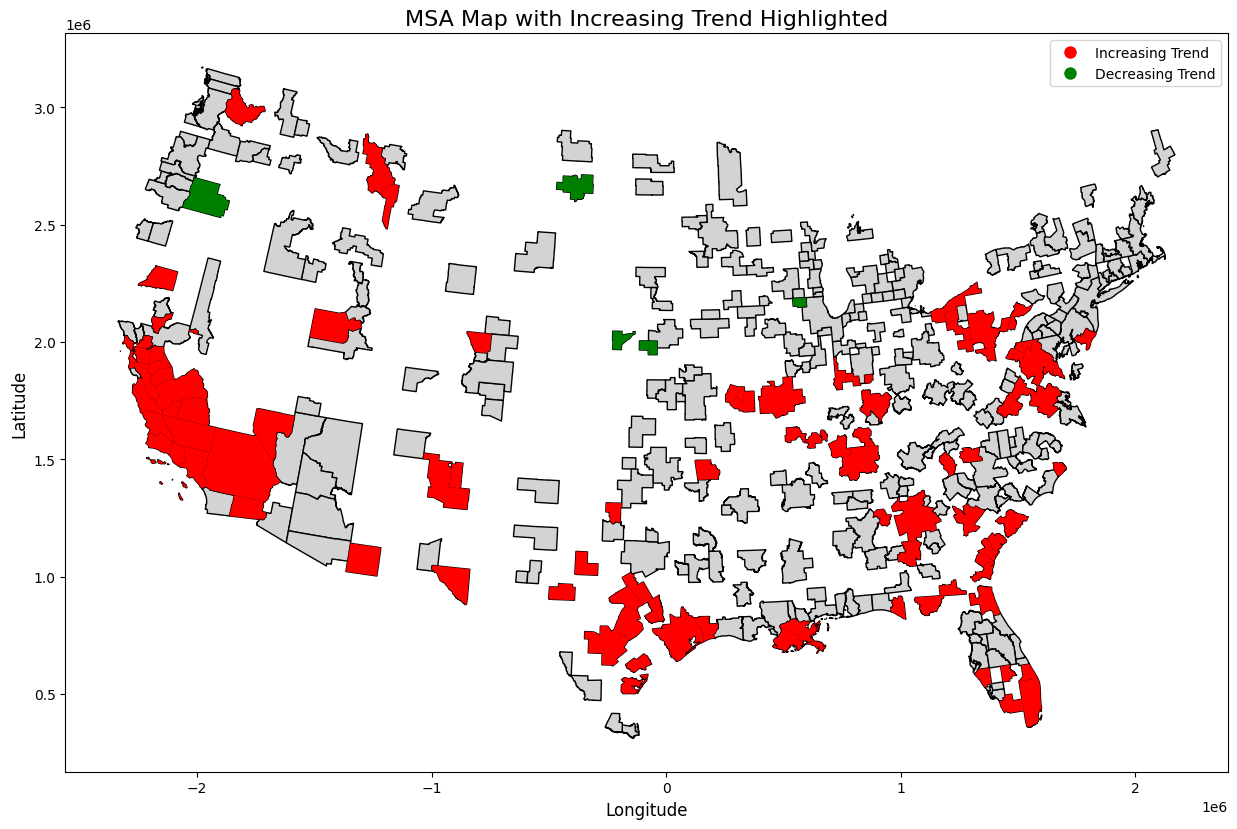

In [ ]:
import geopandas as gpd
from matplotlib.lines import Line2D

# MSA_FILE = r'c:\Users\qifanw\Documents\gis\msa\msaUS_mland_aea1_M1_all.shp'
# Load the shapefile
msa_shp = gpd.read_file(constants.MSA_FILE)

# Plot the shapefile on a map
fig, ax = plt.subplots(figsize=(15, 10))
msa_shp.plot(ax=ax, color='lightgrey', edgecolor='black')

# Highlight the MSAs with increasing trend in red
highlighted = msa_shp[msa_shp['NAMELSAD'].isin(increasing_msa['NAMELSAD'])]
highlighted.plot(ax=ax, color='red')
# Highlight the MSAs with decreasing trend in green
decreasing = msa_shp[msa_shp['NAMELSAD'].isin(nee_trend[nee_trend['trend'] == 'decreasing']['NAMELSAD'])]
decreasing.plot(ax=ax, color='green', label='Decreasing Trend')

# Add legend handles manually
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Increasing Trend', markerfacecolor='red', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Decreasing Trend', markerfacecolor='green', markersize=10)
]
ax.legend(handles=legend_elements, loc='upper right')

# Add title and labels
ax.set_title('MSA Map with Increasing Trend Highlighted', fontsize=16)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

plt.show()



### functions and file loading

In [6]:
def deseasonize_df(df):
    '''
    df: DataFrame with datetime index and a single column of data
        e.g. columns = ['NAMELSAD', '200101', '200102', ...] or ['NAMELSAD', 'nee_mean_200101', 'nee_mean_200102', ...]

    Returns a DataFrame with the seasonal cycle removed, by subtracting the average of all Januarys from each Januray value (same for Feb, Mar ...etc). 
    '''
    monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()
    for month in monthly_avg.columns:
        df.loc[:, df.columns.str.endswith(month)] -= monthly_avg[month].values[:, None]
    return df

def mk_trend_test(df, alpha=0.05, name='NAMELSAD'):
    """
    Perform the Mann-Kendall trend test on each row of the DataFrame.
    
    Parameters:
        df (pd.DataFrame): DataFrame with time series data.
            assuming the first column is the index (e.g., NAMELSAD). the rest are time series values.
        name (str): Name of the first column in the DataFrame ('NAMELSAD' in this case).
        alpha (float): Significance level for the test.
        
    Returns:
        pd.DataFrame: DataFrame with trend test results.
    """
    results = []
    for index, row in df.iterrows():
        msa_data = row.iloc[1:].values.flatten()

        # Perform the Mann-Kendall test
        result = mk.original_test(msa_data, alpha=0.05)
        results.append([row[name], result.p, result.slope, result.trend])
    
    return pd.DataFrame(results, columns=[name, 'p', 'slope', 'trend'], index=df.index)

import geopandas as gpd
from matplotlib.lines import Line2D

def plot_trend_map(msa_shp, trend_df, title):
    '''
    Plot the trend map for the given MSA shapefile and trend DataFrame.

    msa_shp: GeoDataFrame containing the MSA shapefile.
    trend_df: DataFrame calculated from the Mann-Kendall test results.
    title: Title for the plot. e.g. 'ppt', 'tmean', 'tdmean'.
    '''

    # Plot the shapefile on a map
    fig, ax = plt.subplots(figsize=(15, 10))
    msa_shp.plot(ax=ax, color='lightgrey', edgecolor='black')

    # Highlight the MSAs with increasing trend in red
    highlighted = msa_shp[msa_shp['NAMELSAD'].isin(trend_df[trend_df['trend'] == 'increasing']['NAMELSAD'])]
    highlighted.plot(ax=ax, color='red')
    # Highlight the MSAs with decreasing trend in green
    decreasing = msa_shp[msa_shp['NAMELSAD'].isin(trend_df[trend_df['trend'] == 'decreasing']['NAMELSAD'])]
    decreasing.plot(ax=ax, color='green')

    # Add legend handles manually
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Increasing Trend', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Decreasing Trend', markerfacecolor='green', markersize=10)
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    # Add title and labels
    ax.set_title(f'Trend Map for {title}', fontsize=16)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)

    plt.show()

def print_trend_brief_info(trend_df, c_i, show_msa=False):
    """
    Print the number of increasing and decreasing trends for a given climate index.
    
    Parameters:
        trend_df (pd.DataFrame): DataFrame containing trend results.
        c_i (str): Climate index name (e.g., 'ppt', 'tmean', 'tdmean').
    """
    increasing = trend_df[trend_df['trend'] == 'increasing']
    decreasing = trend_df[trend_df['trend'] == 'decreasing']
    
    if increasing.empty:
        print(f'No increasing MSAs found for {c_i}.')
    else:
        print(f"Number of increasing {c_i} MSAs: {len(increasing)}")
        if show_msa:
            print('increasing MSAs:', increasing['NAMELSAD'].values)

    if decreasing.empty:
        print(f'No decreasing MSAs found for {c_i}.')
    else:
        print(f"Number of decreasing {c_i} MSAs: {len(decreasing)}")
        if show_msa:
            print('decreasing MSAs:', decreasing['NAMELSAD'].values)

In [4]:
msa_shp = gpd.read_file(constants.MSA_FILE)
msa_region_name = pd.read_csv(constants.MSA_NAME_REGION_TABLE)

### PRISM Climate Vars

C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_19280\1303994728.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()


Number of increasing nee MSAs: 100
Number of decreasing nee MSAs: 5


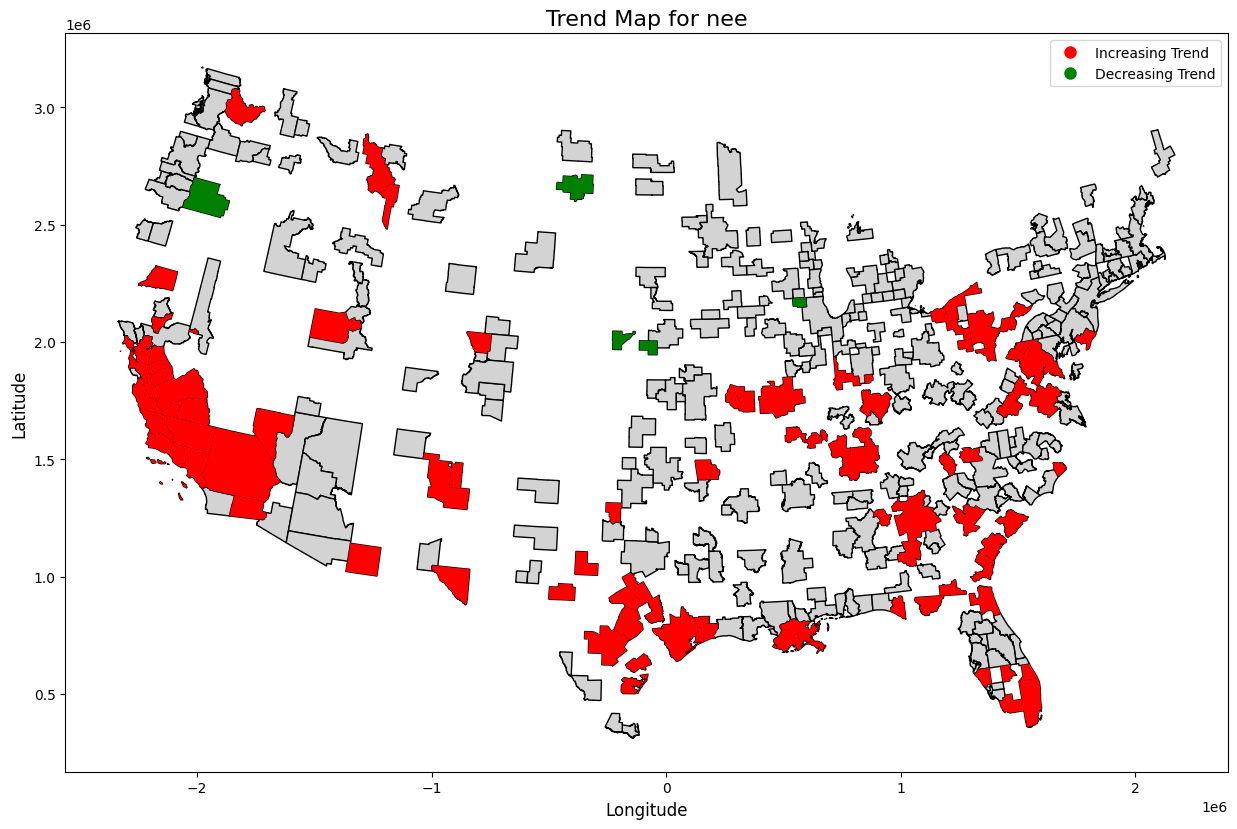

In [7]:
nee_df = pd.read_csv(constants.NEE_MSA_MONTHLY_MEAN)
nee_trend = mk_trend_test(deseasonize_df(nee_df))
print_trend_brief_info(nee_trend, 'nee', show_msa=False)
plot_trend_map(msa_shp, nee_trend, 'nee')

C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_19280\1303994728.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()
C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_19280\1303994728.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()
C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_19280\1303994728.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()


Number of increasing ppt MSAs: 13
No decreasing MSAs found for ppt.
Number of increasing tmean MSAs: 20
Number of decreasing tmean MSAs: 3
Number of increasing tdmean MSAs: 3
Number of decreasing tdmean MSAs: 168


C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_19280\1303994728.py:57: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  decreasing.plot(ax=ax, color='green')


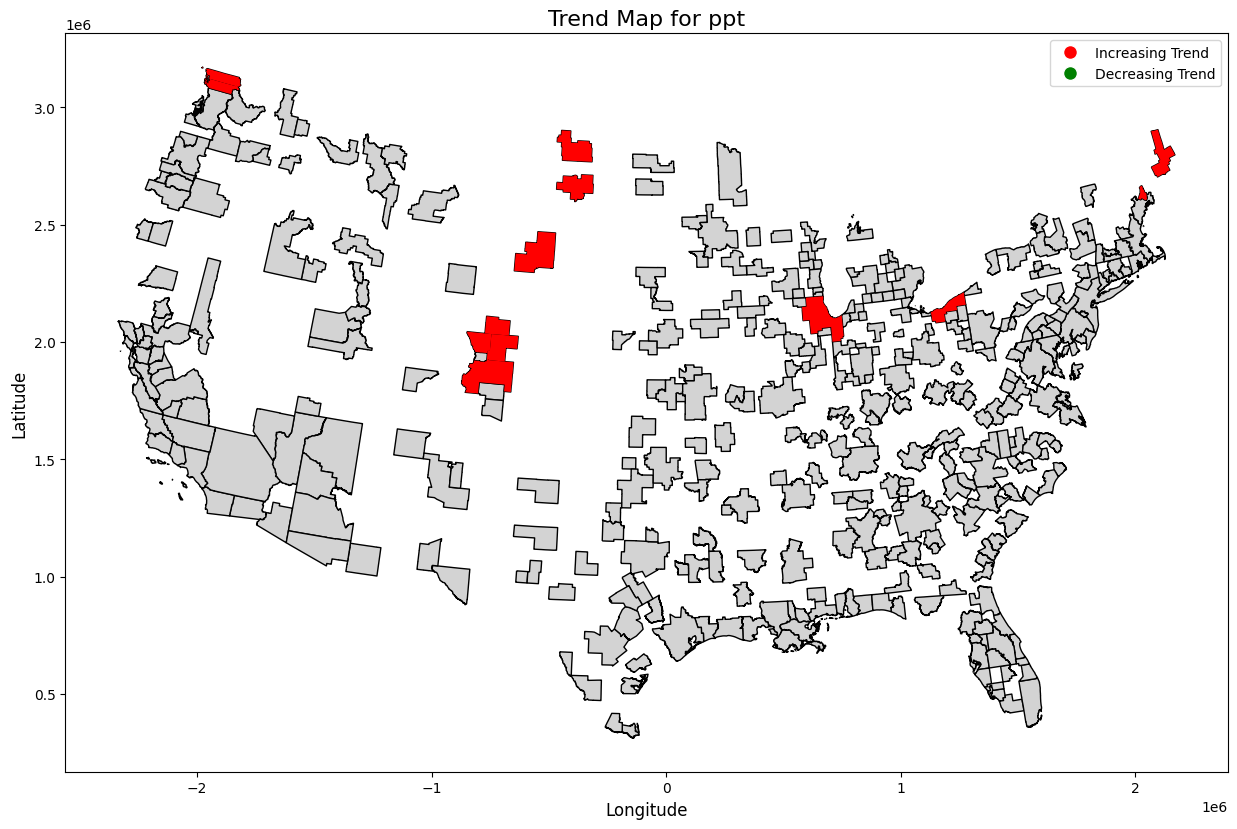

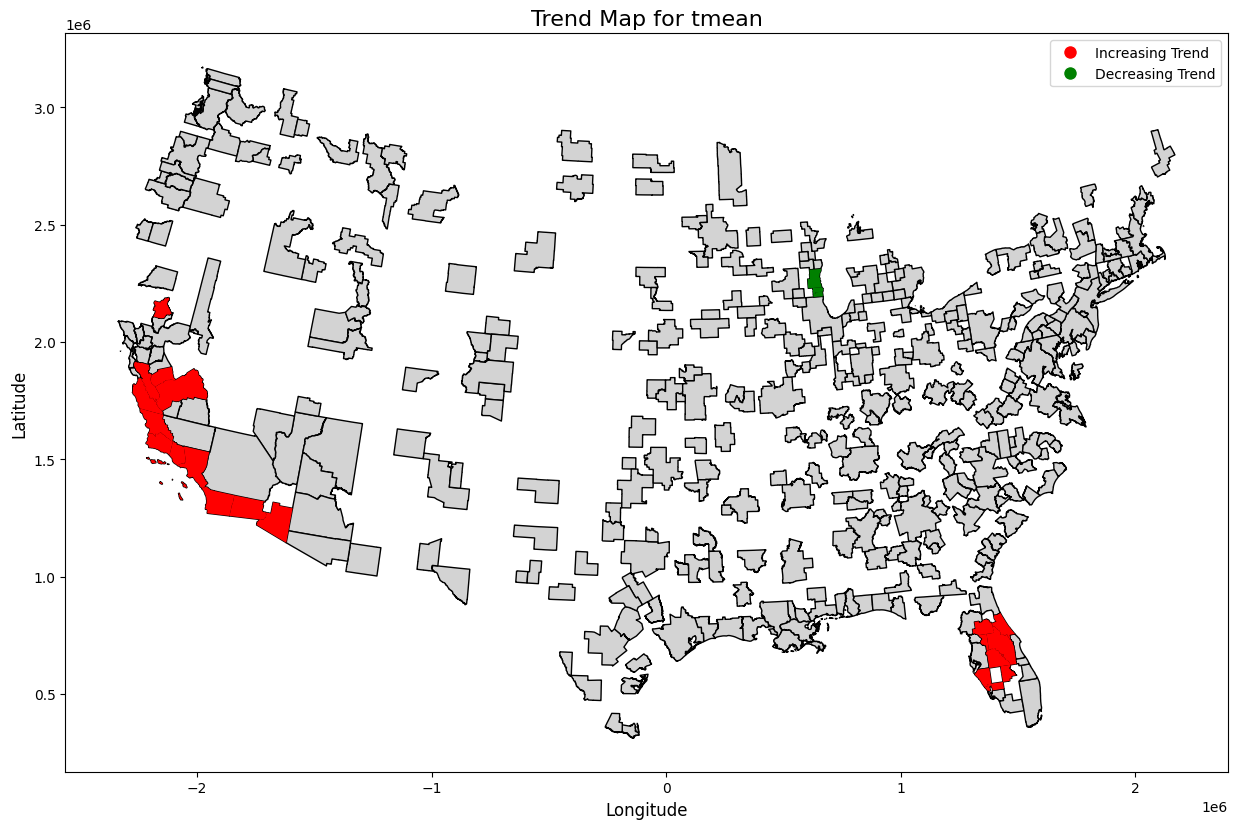

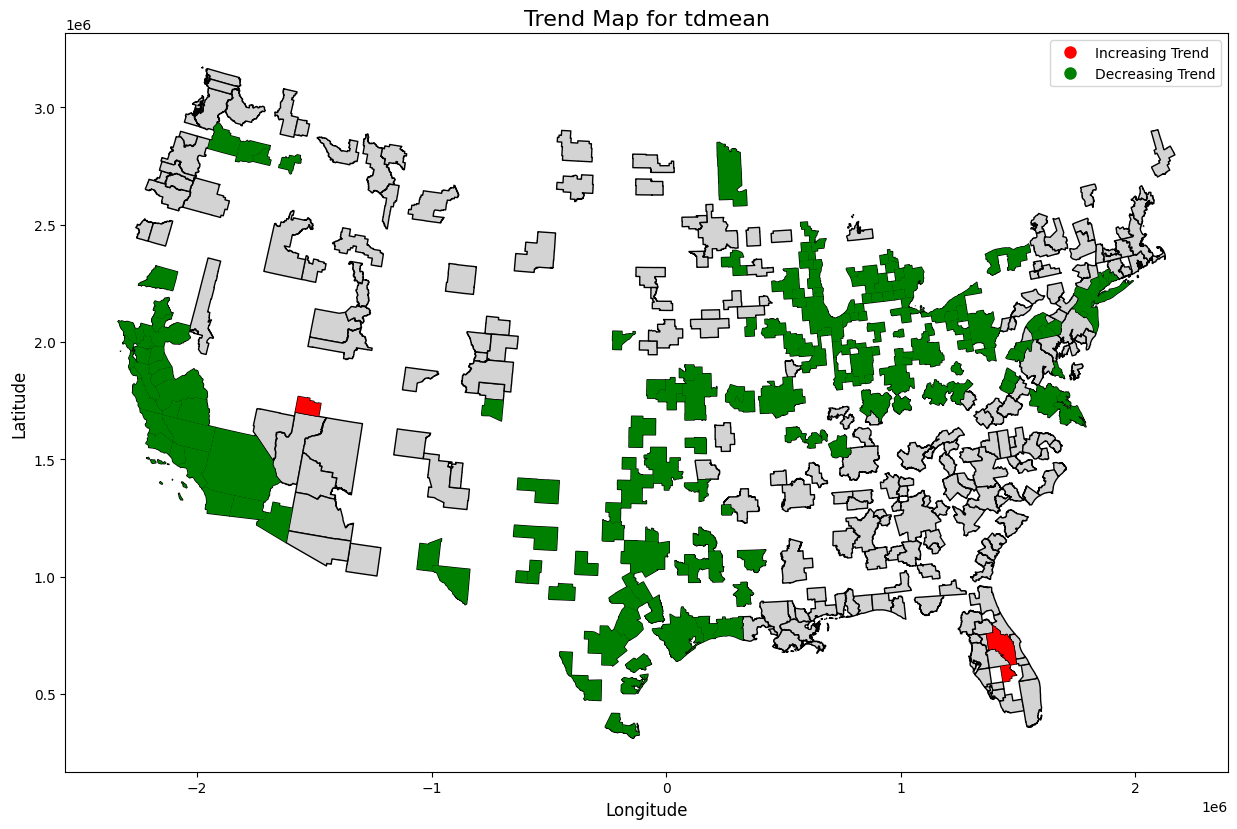

In [8]:
ppt_df = pd.read_csv(constants.PPT_MEAN_FILE).rename(columns={'Unnamed: 0': 'NAMELSAD'})
tmean_df = pd.read_csv(constants.TMEAN_MEAN_FILE).rename(columns={'Unnamed: 0': 'NAMELSAD'})
tdmean_df = pd.read_csv(constants.TDMEAN_MEAN_FILE).rename(columns={'Unnamed: 0': 'NAMELSAD'})

ppt_trend = mk_trend_test(deseasonize_df(ppt_df))
tdmean_trend = mk_trend_test(deseasonize_df(tdmean_df))
tmean_trend = mk_trend_test(deseasonize_df(tmean_df))

for c_i, trend_df in {'ppt':ppt_trend, 'tmean':tmean_trend, 'tdmean':tdmean_trend}.items():
    print_trend_brief_info(trend_df, c_i, show_msa=False)

plot_trend_map(msa_shp, ppt_trend, 'ppt')
plot_trend_map(msa_shp, tmean_trend, 'tmean')
plot_trend_map(msa_shp, tdmean_trend, 'tdmean')

### SIF

In [9]:
sif_df = pd.read_csv(constants.SIF_MEAN_FILE).rename(columns={'Unnamed: 0': 'NAMELSAD'})
sif_trend = mk_trend_test(deseasonize_df(sif_df))
print_trend_brief_info(sif_trend, 'sif', show_msa=False)

C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_19280\1303994728.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()


Number of increasing sif MSAs: 54
Number of decreasing sif MSAs: 55


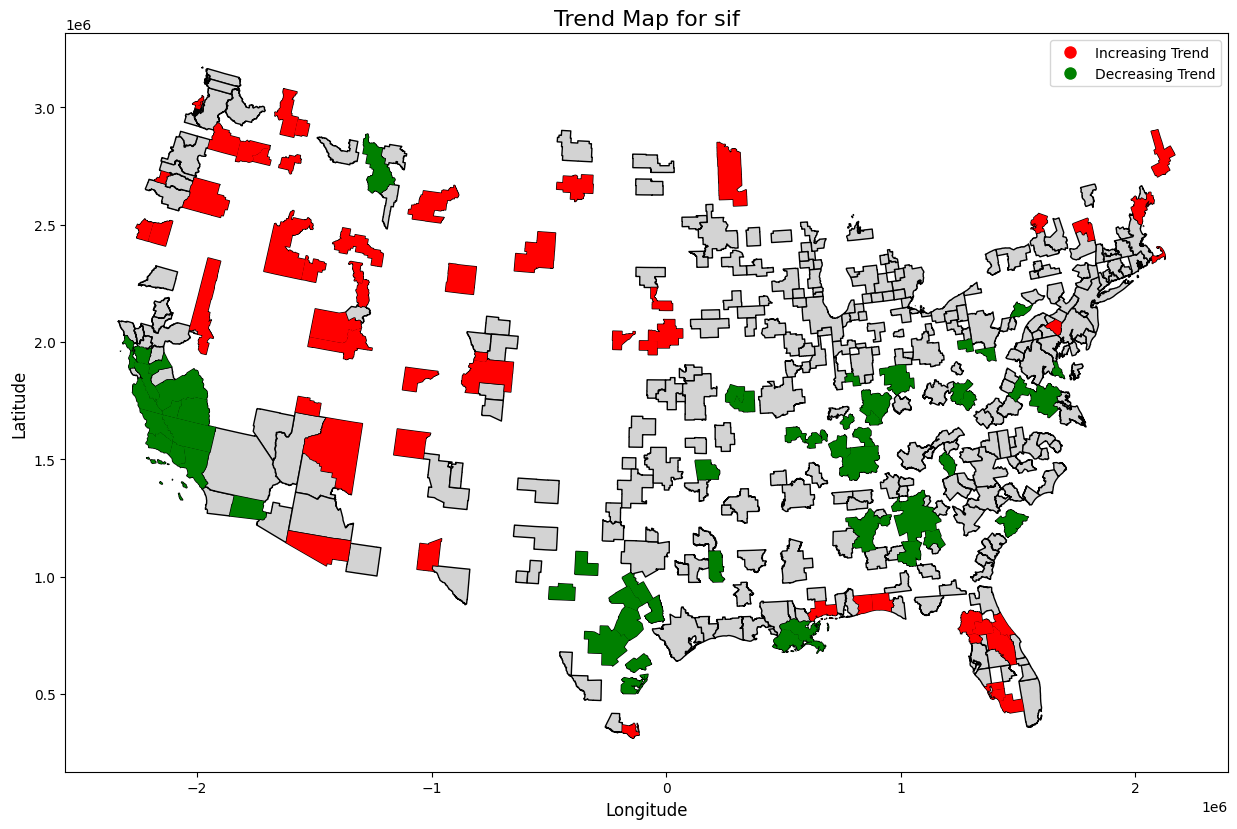

In [10]:
plot_trend_map(msa_shp, sif_trend, 'sif')